In [ ]:
!pip install torch torchvision opencv-python matplotlib


In [ ]:
!pip install opencv-python opencv-python-headless

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import zipfile
import os

zip_path = '/content/drive/MyDrive/ap-10k.zip'
extract_path = '/content/AP-10K'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted to:", extract_path)

Dataset extracted to: /content/AP-10K


In [ ]:
os.listdir(extract_path)

['ap-10k']

In [ ]:
for root, dirs, files in os.walk(extract_path):
    print(root, len(files))

/content/AP-10K 0
/content/AP-10K/ap-10k 0
/content/AP-10K/ap-10k/annotations 9
/content/AP-10K/ap-10k/data 10015


In [ ]:
from glob import glob
import os

# Correct path to images
image_folder = '/content/AP-10K/ap-10k/data'
image_paths = glob(os.path.join(image_folder, '*.jpg'))  # not recursive, all images are flat

print(f'Total images: {len(image_paths)}')
print("First 5 images:", image_paths[:5])

Total images: 10015
First 5 images: ['/content/AP-10K/ap-10k/data/000000031876.jpg', '/content/AP-10K/ap-10k/data/000000038917.jpg', '/content/AP-10K/ap-10k/data/000000039927.jpg', '/content/AP-10K/ap-10k/data/000000043274.jpg', '/content/AP-10K/ap-10k/data/000000049078.jpg']


In [ ]:
import random

random.seed(42)  # for reproducibility
subset_size = 1000

subset_image_paths = random.sample(image_paths, subset_size)
print(f"Selected {len(subset_image_paths)} images")

Selected 1000 images


In [ ]:
!pip uninstall -y mediapipe
!pip install mediapipe==0.10.14

import mediapipe as mp
# This should now work without the AttributeError
mp_pose = mp.solutions.pose
print("Legacy solutions successfully loaded.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.7/35.7 MB 45.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.2/295.2 kB 14.2 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.6
    Uninstalling protobuf-5.29.6:
      Successfully uninstalled protobuf-5.29.6
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ydf 0.15.0 requires protobuf<7.0.0,>=5.29.1, but you have protobuf 4.25.9 which is incompatible.
opentelemetry-proto 1.38.0 requires protobuf<7.0,>=5.0, but you have protobuf 4.25.9 which is incompatible.
grain 0.2.16 requires protobuf>=5.28.3, but you have protobuf 4.25.9 which is incompatible.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 4.25.9 which is incompatible.


Legacy solutions successfully loaded.


In [ ]:
# 1. Force the downgrade
!pip uninstall -y mediapipe
!pip install mediapipe==0.10.14

# 2. Clear out any residual imports
import sys
if 'mediapipe' in sys.modules:
    del sys.modules['mediapipe']

import mediapipe as mp
print(f"MediaPipe version now: {mp.__version__}")
# Test if 'solutions' exists now
try:
    print("Success! mp.solutions is available:", hasattr(mp, 'solutions'))
except:
    print("If this fails, click 'Restart Session' in the Colab menu and run this cell again.")

Found existing installation: mediapipe 0.10.14
Uninstalling mediapipe-0.10.14:
  Successfully uninstalled mediapipe-0.10.14
  Using cached mediapipe-0.10.14-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (9.7 kB)
Using cached mediapipe-0.10.14-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (35.7 MB)


NameError: name 'framework' is not defined

In [ ]:
# Install the version that supports .solutions
!pip install mediapipe==0.10.14 --quiet

import os
import sys

# Function to verify the fix
def check_mediapipe():
    try:
        import mediapipe as mp
        if hasattr(mp, 'solutions'):
            print(f"Success! MediaPipe {mp.__version__} loaded with 'solutions'.")
            return mp
        else:
            print("'solutions' missing. Go to Runtime -> Restart Session and try again.")
    except ImportError:
        print("MediaPipe not found. Run the pip install again.")

mp = check_mediapipe()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.7/35.7 MB 13.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.2/295.2 kB 21.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ydf 0.15.0 requires protobuf<7.0.0,>=5.29.1, but you have protobuf 4.25.9 which is incompatible.
opentelemetry-proto 1.38.0 requires protobuf<7.0,>=5.0, but you have protobuf 4.25.9 which is incompatible.
grain 0.2.16 requires protobuf>=5.28.3, but you have protobuf 4.25.9 which is incompatible.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 4.25.9 which is incompatible.
Success! MediaPipe 0.10.14 loaded with 'solutions'.


In [ ]:
import cv2
import os
import pandas as pd
from tqdm import tqdm

# Initialize MediaPipe Pose
mp_pose = mp.solutions.pose
mp_drawing = mp.solutions.drawing_utils

# Using model_complexity=2 (Heavy) because AP-10K animals vary wildly in shape
pose = mp_pose.Pose(
    static_image_mode=True,
    model_complexity=2,
    min_detection_confidence=0.2
)

extracted_data = []

print(f"Analyzing {len(subset_image_paths)} animal images...")

for img_path in tqdm(subset_image_paths):
    img = cv2.imread(img_path)
    if img is None: continue

    # Convert BGR to RGB for MediaPipe
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    results = pose.process(img_rgb)

    if results.pose_landmarks:
        # Flatten the 33 landmarks into a list [x1, y1, z1, v1, x2, y2...]
        row = []
        for lm in results.pose_landmarks.landmark:
            row.extend([lm.x, lm.y, lm.z, lm.visibility])

        extracted_data.append({
            'filename': os.path.basename(img_path),
            'keypoints': row
        })

# Save to a CSV for your downstream tasks
df = pd.DataFrame(extracted_data)
df.to_csv('ap10k_mediapipe_results.csv', index=False)

print(f"\nFinished! Detected poses in {len(df)} images.")
print("Results saved to 'ap10k_mediapipe_results.csv'")

Analyzing 1000 animal images...


  0%|          | 3/1000 [00:00<02:06,  7.91it/s]/usr/local/lib/python3.12/dist-packages/google/protobuf/symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '
100%|██████████| 1000/1000 [01:23<00:00, 11.95it/s]


Finished! Detected poses in 163 images.
Results saved to 'ap10k_mediapipe_results.csv'


In [ ]:
import pandas as pd
from google.colab import files

# 1. Save locally in the Colab VM
df = pd.DataFrame(extracted_data)
df.to_csv('mediapipe_results.csv', index=False)

# 2. Copy to your Google Drive (the path you used earlier)
# This ensures you don't lose the data if the session times out
!cp mediapipe_results.csv '/content/drive/MyDrive/mediapipe_results_ap10k.csv'

print("Results backed up to Drive.")

Results backed up to Drive.


In [ ]:
total_requested = len(subset_image_paths)
total_detected = len(extracted_data)
detection_rate = (total_detected / total_requested) * 100

print(f"--- Evaluation Summary ---")
print(f"Total Images: {total_requested}")
print(f"Successful Detections: {total_detected}")
print(f"Detection Rate: {detection_rate:.2f}%")

if detection_rate < 50:
    print("Warning: Low detection rate. Consider lowering 'min_detection_confidence' to 0.2 or 0.3.")

--- Evaluation Summary ---
Total Images: 1000
Successful Detections: 163
Detection Rate: 16.30%


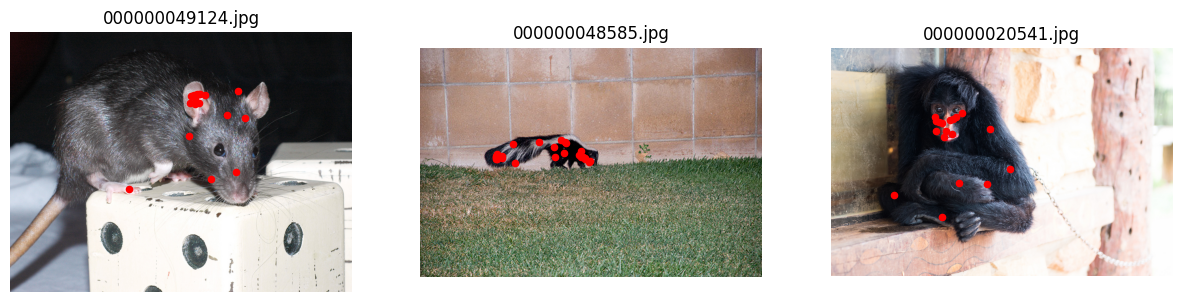

In [ ]:
import matplotlib.pyplot as plt
import random

def plot_random_results(num_samples=3):
    samples = random.sample(extracted_data, min(num_samples, len(extracted_data)))

    plt.figure(figsize=(15, 5))
    for i, sample in enumerate(samples):
        img_path = os.path.join(image_folder, sample['filename'])
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # Draw landmarks manually from the saved data
        # Data is stored as [x1, y1, z1, v1, ...]
        plt.subplot(1, num_samples, i+1)
        plt.imshow(img)

        # Extract X and Y (normalized 0-1) and scale to image size
        h, w, _ = img.shape
        kpts = sample['keypoints']
        for j in range(0, len(kpts), 4):
            x, y = int(kpts[j] * w), int(kpts[j+1] * h)
            vis = kpts[j+3]
            if vis > 0.5: # Only plot confident points
                plt.scatter(x, y, s=20, c='red')

        plt.title(sample['filename'])
        plt.axis('off')
    plt.show()

plot_random_results()

/tmp/ipykernel_1689/3774260350.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=quality_labels, y=quality_values, palette='viridis', ax=axes[0,1])


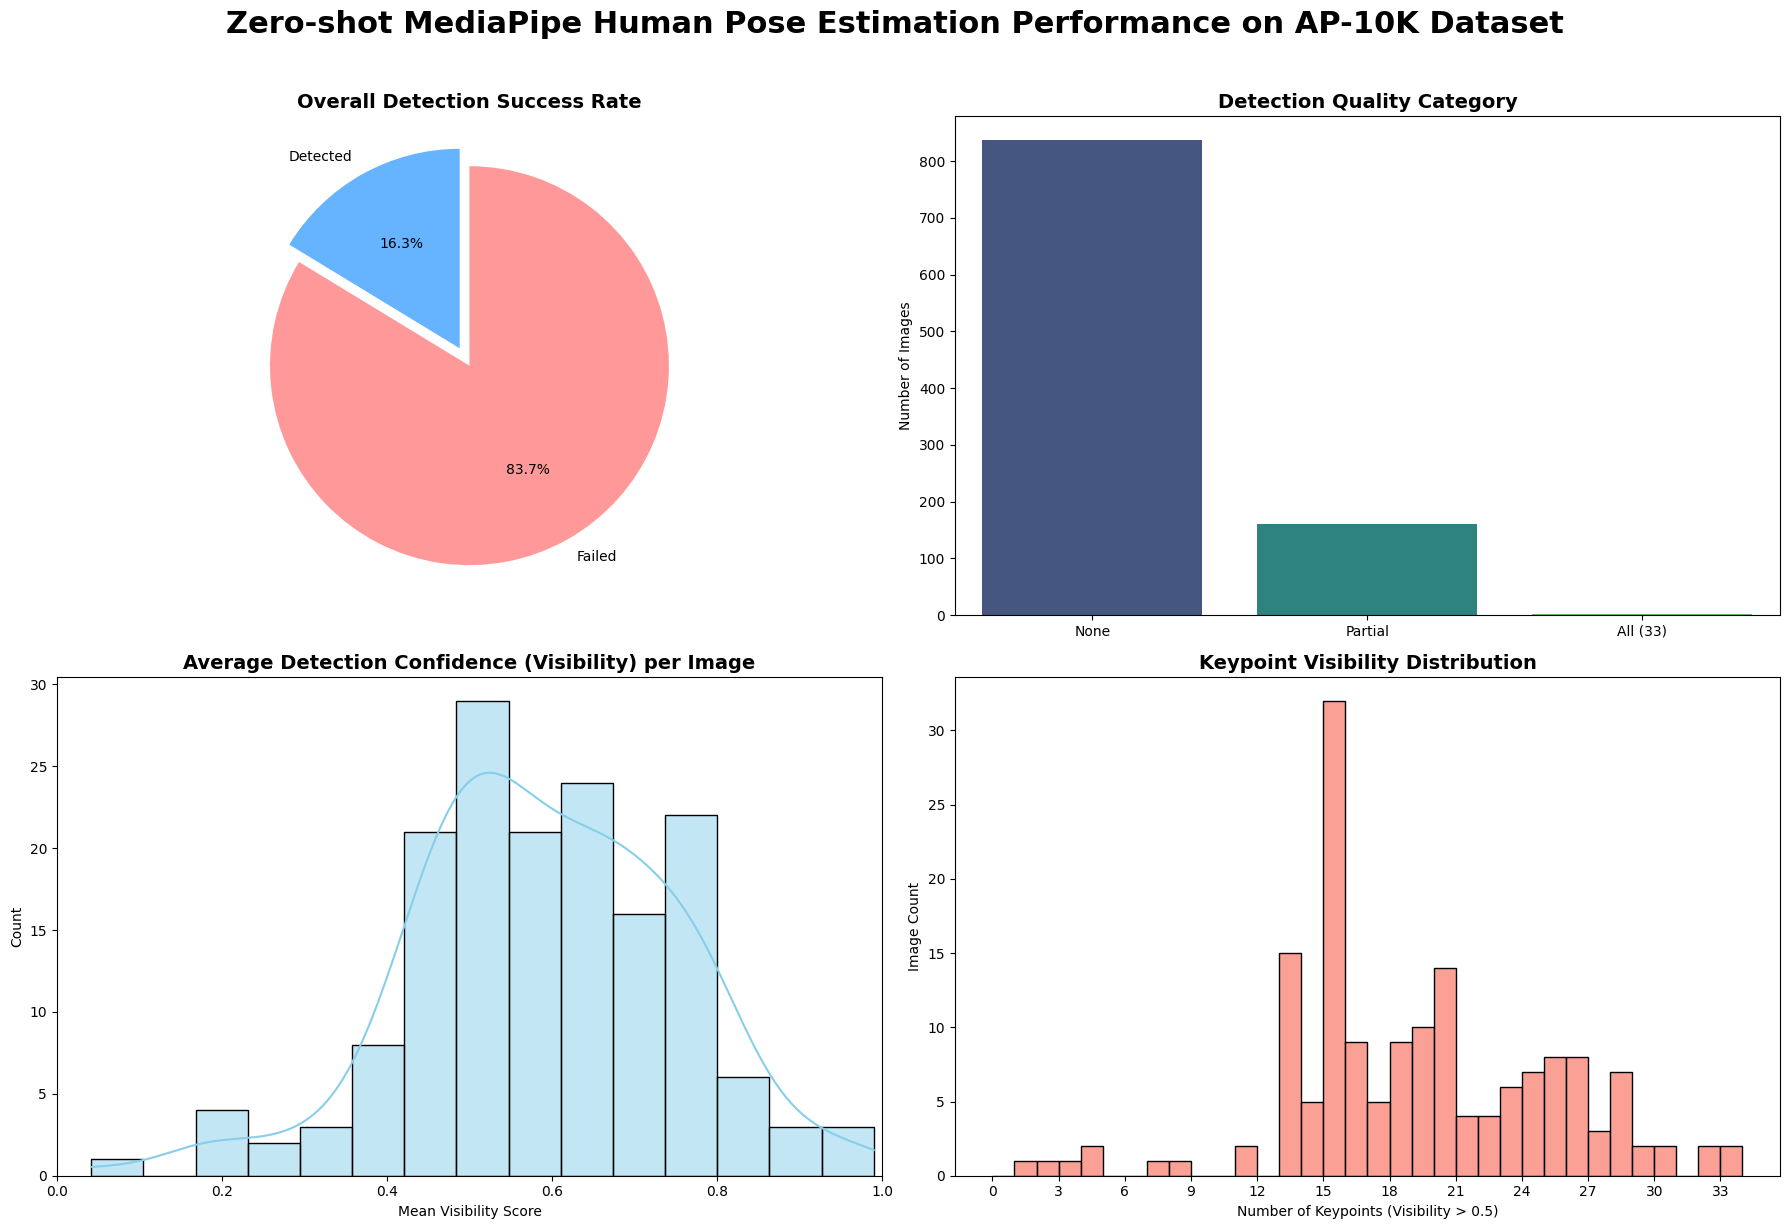

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# --- 1. DATA PROCESSING ---
VISIBILITY_THRESHOLD = 0.5

# Prepare stats for the charts
total_requested = len(subset_image_paths)
total_detected = len(extracted_data)
total_failed = total_requested - total_detected

all_confidences = []
visible_keypoint_counts = []
none_count = total_failed
partial_count = 0
full_count = 0

for entry in extracted_data:
    kpts = entry['keypoints']
    # Visibility is every 4th element [x, y, z, visibility, ...]
    visibilities = [kpts[i] for i in range(3, len(kpts), 4)]

    # Calculation for Confidence Distribution
    avg_vis = np.mean(visibilities)
    all_confidences.append(avg_vis)

    # Calculation for Keypoint Visibility Distribution
    num_visible = sum(1 for v in visibilities if v > VISIBILITY_THRESHOLD)
    visible_keypoint_counts.append(num_visible)

    # Logic for Quality Categories
    if num_visible == 33:
        full_count += 1
    elif num_visible > 0:
        partial_count += 1
    else:
        none_count += 1

# --- 2. PLOTTING THE 2x2 DASHBOARD ---
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
plt.subplots_adjust(hspace=0.3)

# Plot 1: Overall Success Rate (Pie)
axes[0,0].pie([total_detected, total_failed], labels=['Detected', 'Failed'],
              autopct='%1.1f%%', colors=['#66b3ff', '#ff9999'], startangle=90, explode=(0.1, 0))
axes[0,0].set_title('Overall Detection Success Rate', fontsize=14, fontweight='bold')

# Plot 2: Detection Quality Categories (Bar)
quality_labels = ['None', 'Partial', 'All (33)']
quality_values = [none_count, partial_count, full_count]
sns.barplot(x=quality_labels, y=quality_values, palette='viridis', ax=axes[0,1])
axes[0,1].set_title('Detection Quality Category', fontsize=14, fontweight='bold')
axes[0,1].set_ylabel('Number of Images')

# Plot 3: Average Confidence Distribution (Histogram)
sns.histplot(all_confidences, bins=15, kde=True, color='skyblue', ax=axes[1,0])
axes[1,0].set_title('Average Detection Confidence (Visibility) per Image', fontsize=14, fontweight='bold')
axes[1,0].set_xlabel('Mean Visibility Score')
axes[1,0].set_xlim(0, 1)

# Plot 4: Keypoint Visibility Distribution (New Chart)
# Shows how many of the 33 points were actually seen per image
sns.histplot(visible_keypoint_counts, bins=range(35), color='salmon', ax=axes[1,1])
axes[1,1].set_title('Keypoint Visibility Distribution', fontsize=14, fontweight='bold')
axes[1,1].set_xlabel(f'Number of Keypoints (Visibility > {VISIBILITY_THRESHOLD})')
axes[1,1].set_ylabel('Image Count')
axes[1,1].set_xticks(range(0, 34, 3)) # Label every 3rd point for clarity


fig.suptitle('Zero-shot MediaPipe Human Pose Estimation Performance on AP-10K Dataset', fontsize=22, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig('ap10k_mediapipe_dashboard.png')
plt.show()

In [ ]:
# NEXT STEP
# If you are trying to keep the human skeleton but detect animals,
# you must map the 17 AP-10K points to the closest 33 MediaPipe indices.
# AP-10K Point 1 (Nose) -> MediaPipe 0 (Nose)
# AP-10K Points 11-12 (Hips) -> MediaPipe 23-24 (Hips)
# The "Tail" Problem: Since MediaPipe lacks a tail landmark, you may need to assign "tail base"
# to an unused human index (like a specific facial landmark) or ignore it entirely.

import numpy as np

# AP-10K indices (Standard 17-point animal format)
# 0: Left Eye, 1: Right Eye, 2: Nose, 3: Left Shoulder, 4: Right Shoulder
# 5: Left Elbow, 6: Right Elbow, 7: Left Wrist, 8: Right Wrist
# 9: Left Hip, 10: Right Hip, 11: Left Knee, 12: Right Knee
# 13: Left Ankle, 14: Right Ankle, 15: Neck, 16: Tailbase

AP10K_TO_MEDIAPIPE = {
    2: 0,   # Nose -> Nose
    0: 2,   # Left Eye -> Left Eye (Outer)
    1: 5,   # Right Eye -> Right Eye (Outer)
    3: 11,  # Left Shoulder (Front Leg) -> Left Shoulder
    4: 12,  # Right Shoulder (Front Leg) -> Right Shoulder
    5: 13,  # Left Elbow (Front Leg) -> Left Elbow
    6: 14,  # Right Elbow (Front Leg) -> Right Elbow
    7: 15,  # Left Wrist (Front Leg) -> Left Wrist
    8: 16,  # Right Wrist (Front Leg) -> Right Wrist
    9: 23,  # Left Hip (Back Leg) -> Left Hip
    10: 24, # Right Hip (Back Leg) -> Right Hip
    11: 25, # Left Knee (Back Leg) -> Left Knee
    12: 26, # Right Knee (Back Leg) -> Right Knee
    13: 27, # Left Ankle (Back Leg) -> Left Ankle
    14: 28, # Right Ankle (Back Leg) -> Right Ankle
    # Tailbase doesn't exist in MP, often mapped to a 'neutral' point
    # or a foot landmark like 'Heel' (29/30) to keep the data.
    16: 31, # Tailbase -> Left Foot Index (arbitrary substitute)
}

def remap_keypoints(ap10k_keypoints):
    """
    Translates an array of AP-10K keypoints (17, 3)
    into MediaPipe format (33, 3).
    """
    # Initialize 33 points with zeros (x, y, visibility)
    mp_landmarks = np.zeros((33, 3))

    for ap_idx, mp_idx in AP10K_TO_MEDIAPIPE.items():
        if ap_idx < len(ap10k_keypoints):
            mp_landmarks[mp_idx] = ap10k_keypoints[ap_idx]

    return mp_landmarks

# Example Usage:
# sample_animal = np.random.rand(17, 3)
# mp_compatible_animal = remap_keypoints(sample_animal)